check gpu

In [1]:
!nvidia-smi

Wed Sep 24 11:27:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.97                 Driver Version: 580.97         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   58C    P8              4W /   60W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [28]:
from ultralytics import YOLO
import torch
from PIL import Image as PILImage
from IPython.display import Image as IPyImage

print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()) if torch.cuda.is_available() else "CPU")

CUDA available: True
Current device: 0
Device name: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
# Load a pretrained YOLOv8 small model
model = YOLO("yolov8s.pt")


Test on Sample image before training

In [5]:
results = model("https://ultralytics.com/images/bus.jpg")  # test on sample image
results[0].show()   # show predictions inside notebook


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 c:\Users\Jin\Documents\Work\2025-1\Digital-Image-Processing\Coin-Counter-Project\bus.jpg: 640x480 4 persons, 1 bus, 84.6ms
Speed: 21.4ms preprocess, 84.6ms inference, 152.3ms postprocess per image at shape (1, 3, 640, 480)


Alternative way of training by RoboFlow

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=800 plots=True

Start Train

In [ ]:
model.train(
    data="dataset/data.yaml",   # path to your dataset config
    epochs=20,
    imgsz=640,
    batch=16,
    plots=True,
    workers=0
)

Continue Training

In [2]:
# Load checkpoint (best or last)
model = YOLO("runs/detect/train/weights/last.pt")

# Continue training on updated dataset
model.train(
    data="dataset/data.yaml",
    epochs=20,     # extra epochs
    imgsz=640,
    batch=16,
    plots=True,
    resume=True,
    workers=0
)

New https://pypi.org/project/ultralytics/8.3.203 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.202  Python-3.12.1 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs\detect\train\weights\last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F11265CE30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [3]:
model = YOLO("runs/detect/train/weights/best.pt")

Validation

In [4]:
metrics = model.val() 

Ultralytics 8.3.202  Python-3.12.1 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 404.5118.0 MB/s, size: 1052.0 KB)
val: Scanning C:\Users\Jin\Documents\Work\2025-1\Digital-Image-Processing\Coin-Counter-Project\dataset\valid\labels.cache... 234 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 234/234 117.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.4it/s 10.7s0.3s
                   all        234        494       0.99      0.993      0.994      0.958
                     1         87        161      0.994      0.981      0.994      0.955
                    10         80        138      0.997          1      0.995      0.956
                     2         49         60      0.982          1      0.995      0.955
                     5         82    

In [22]:
# run evaluation
preds = model("test2.jpg")   # run prediction
preds[0].show()


image 1/1 c:\Users\Jin\Documents\Work\2025-1\Digital-Image-Processing\Coin-Counter-Project\test2.jpg: 640x640 1 10, 3 2s, 150.5ms
Speed: 8.0ms preprocess, 150.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


Analysis


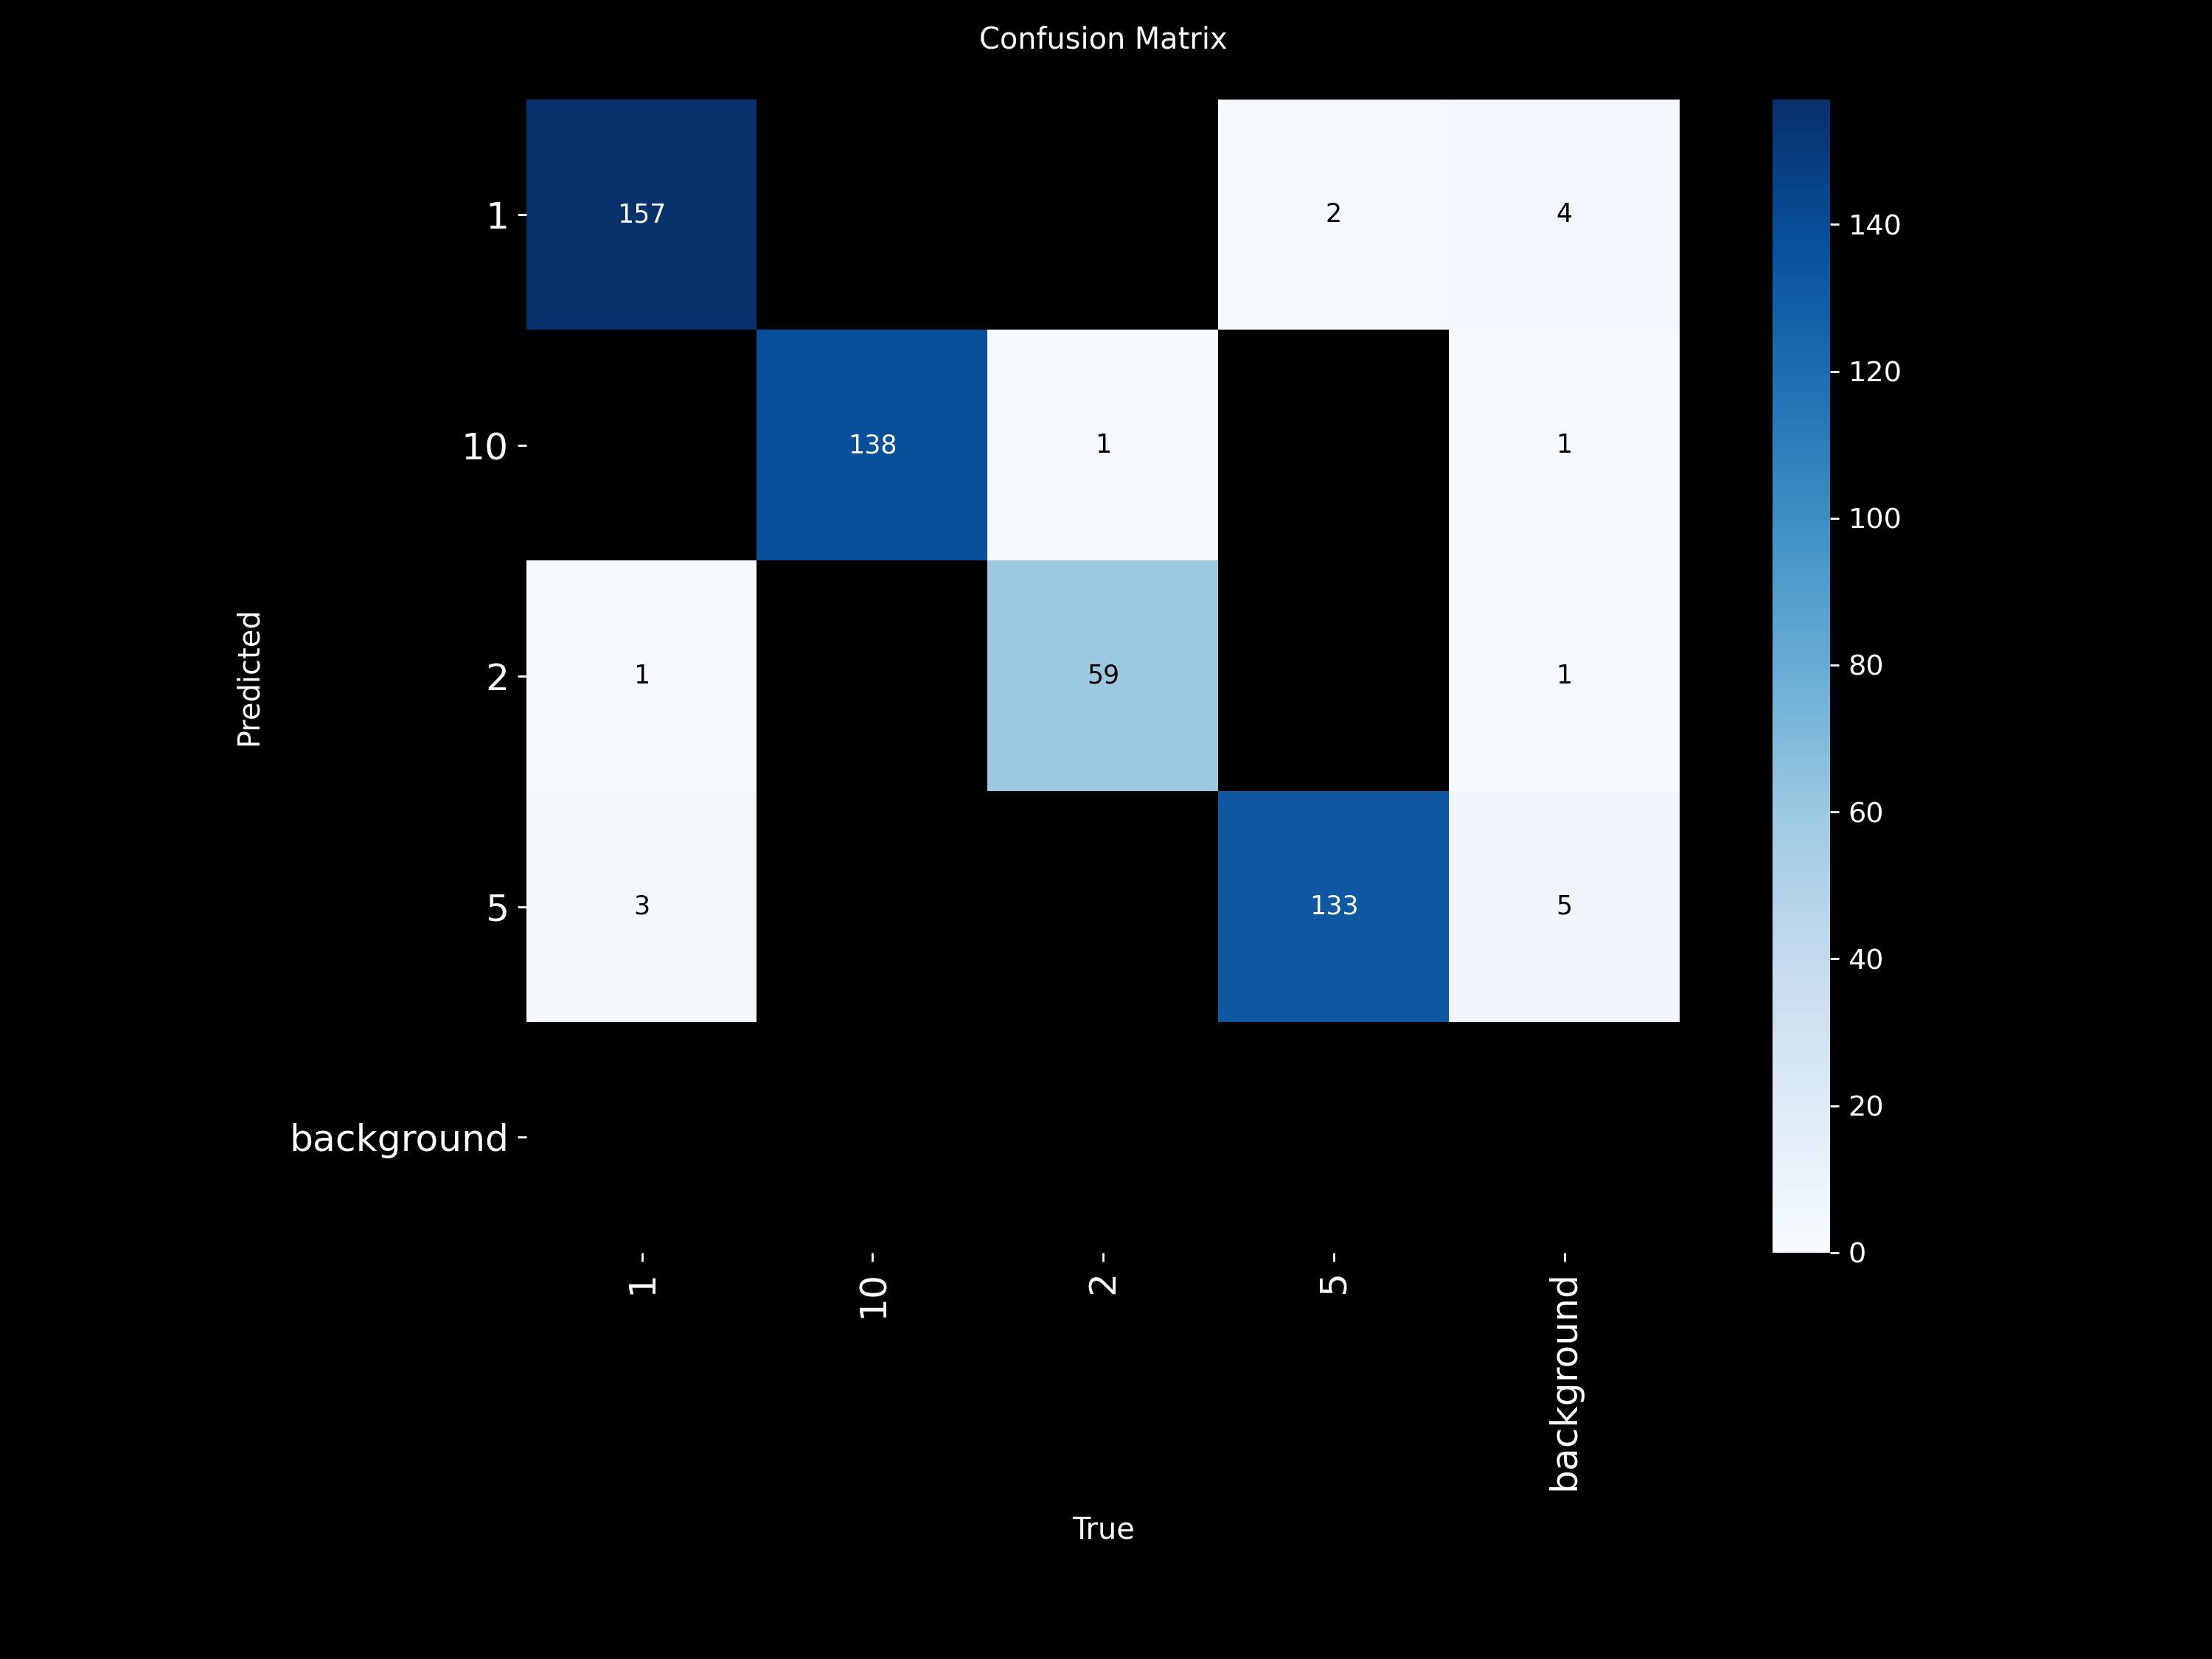

In [31]:
display(IPyImage(filename='runs/detect/train/confusion_matrix.png', width=800))

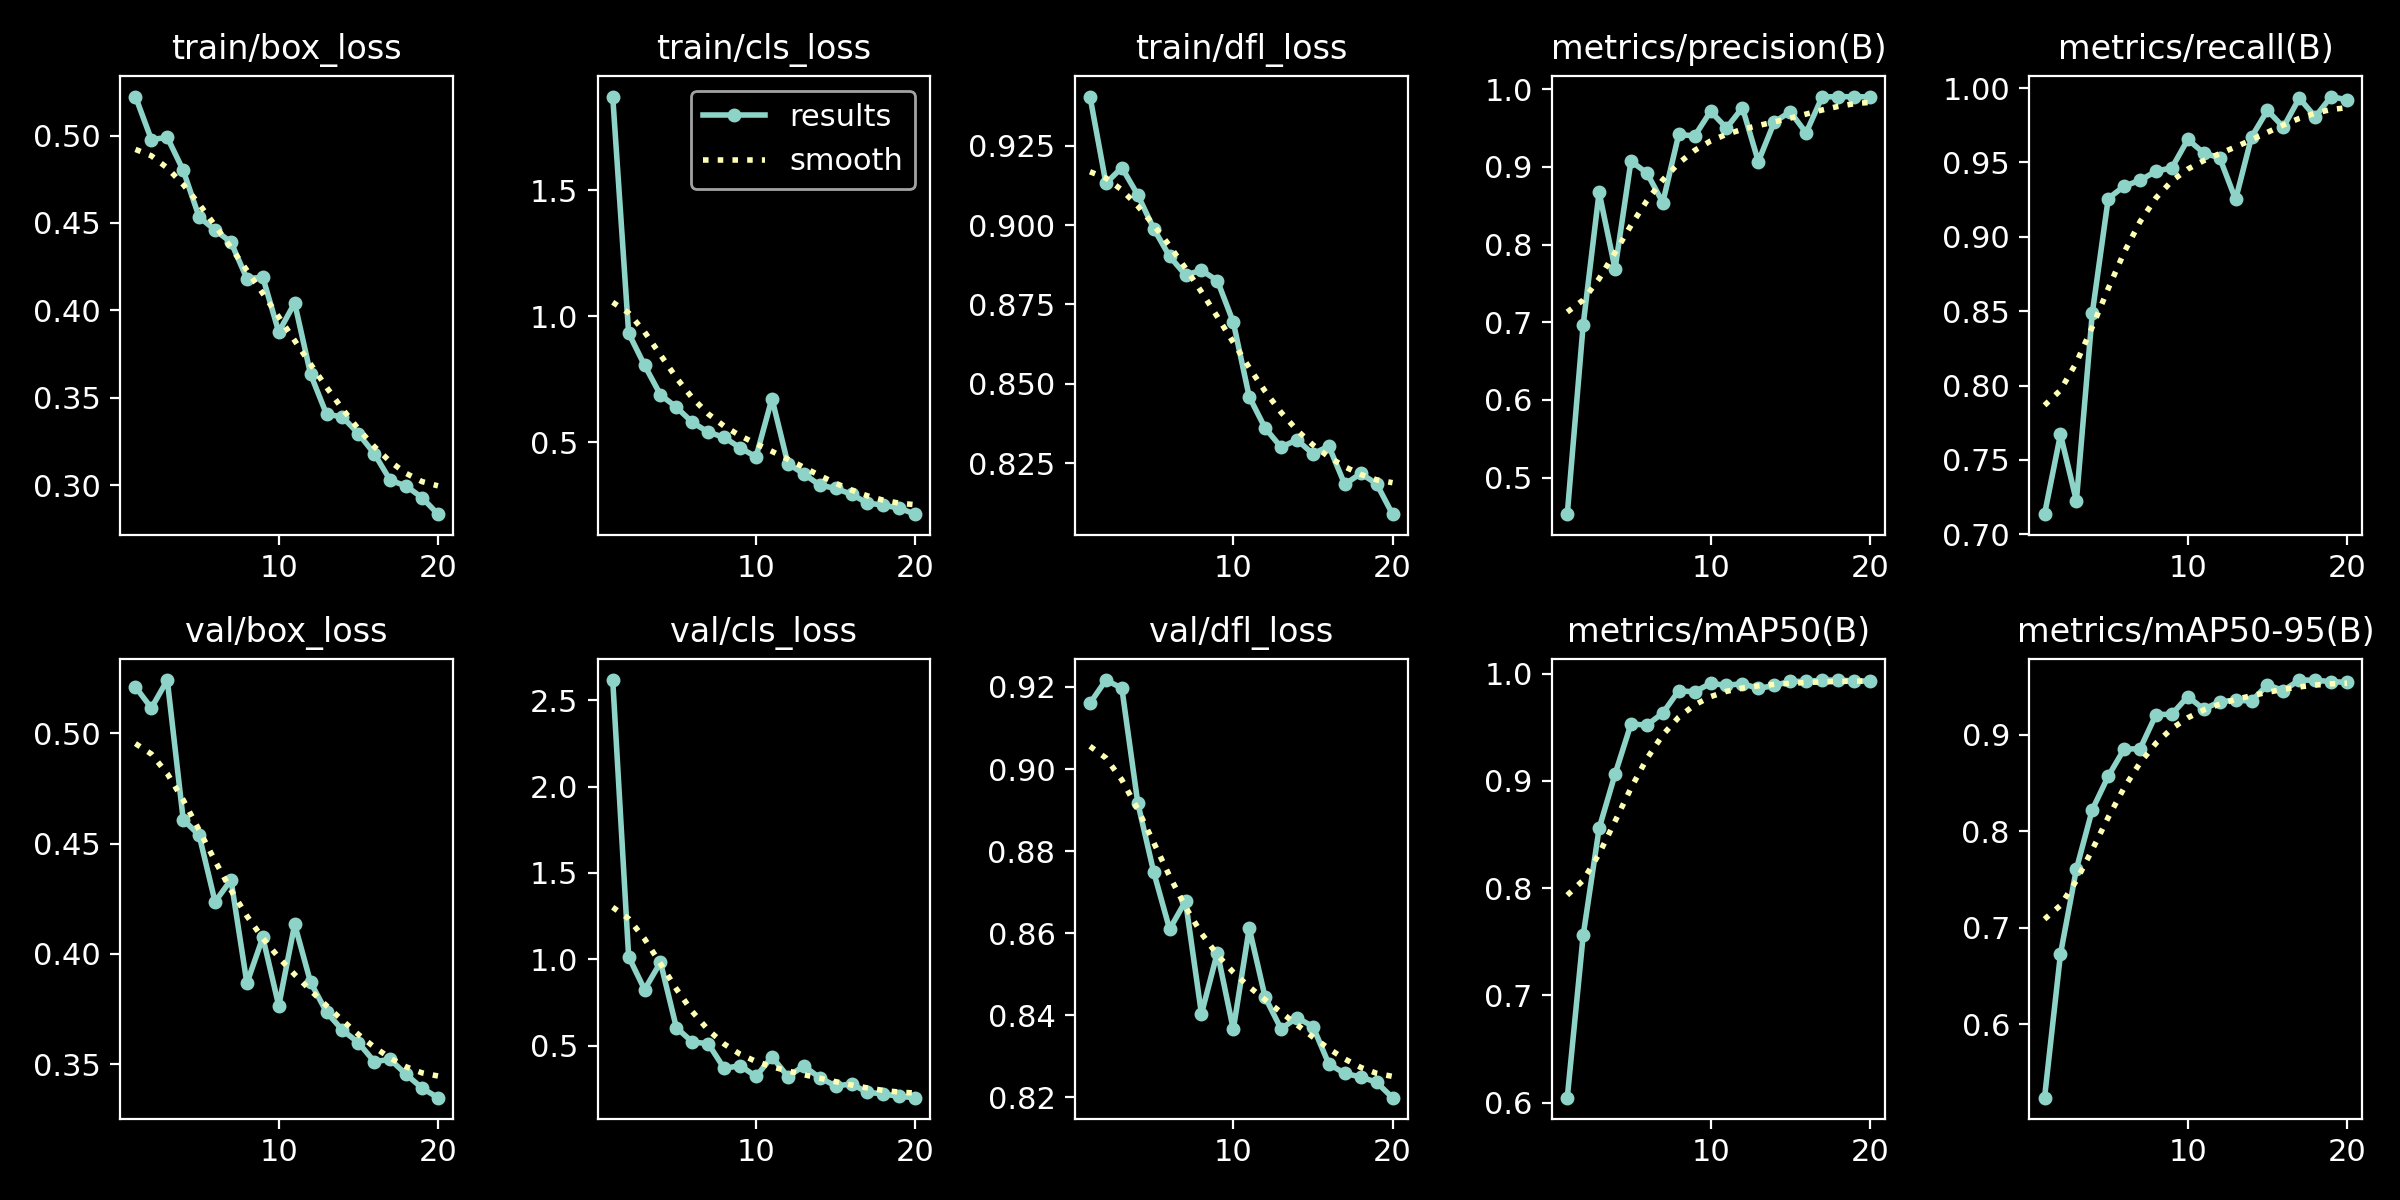

In [ ]:
display(IPyImage(filename=f'runs/detect/train/results.png', width=1000))
# img = PILImage.open("runs/detect/train/results.png")
# img.show()

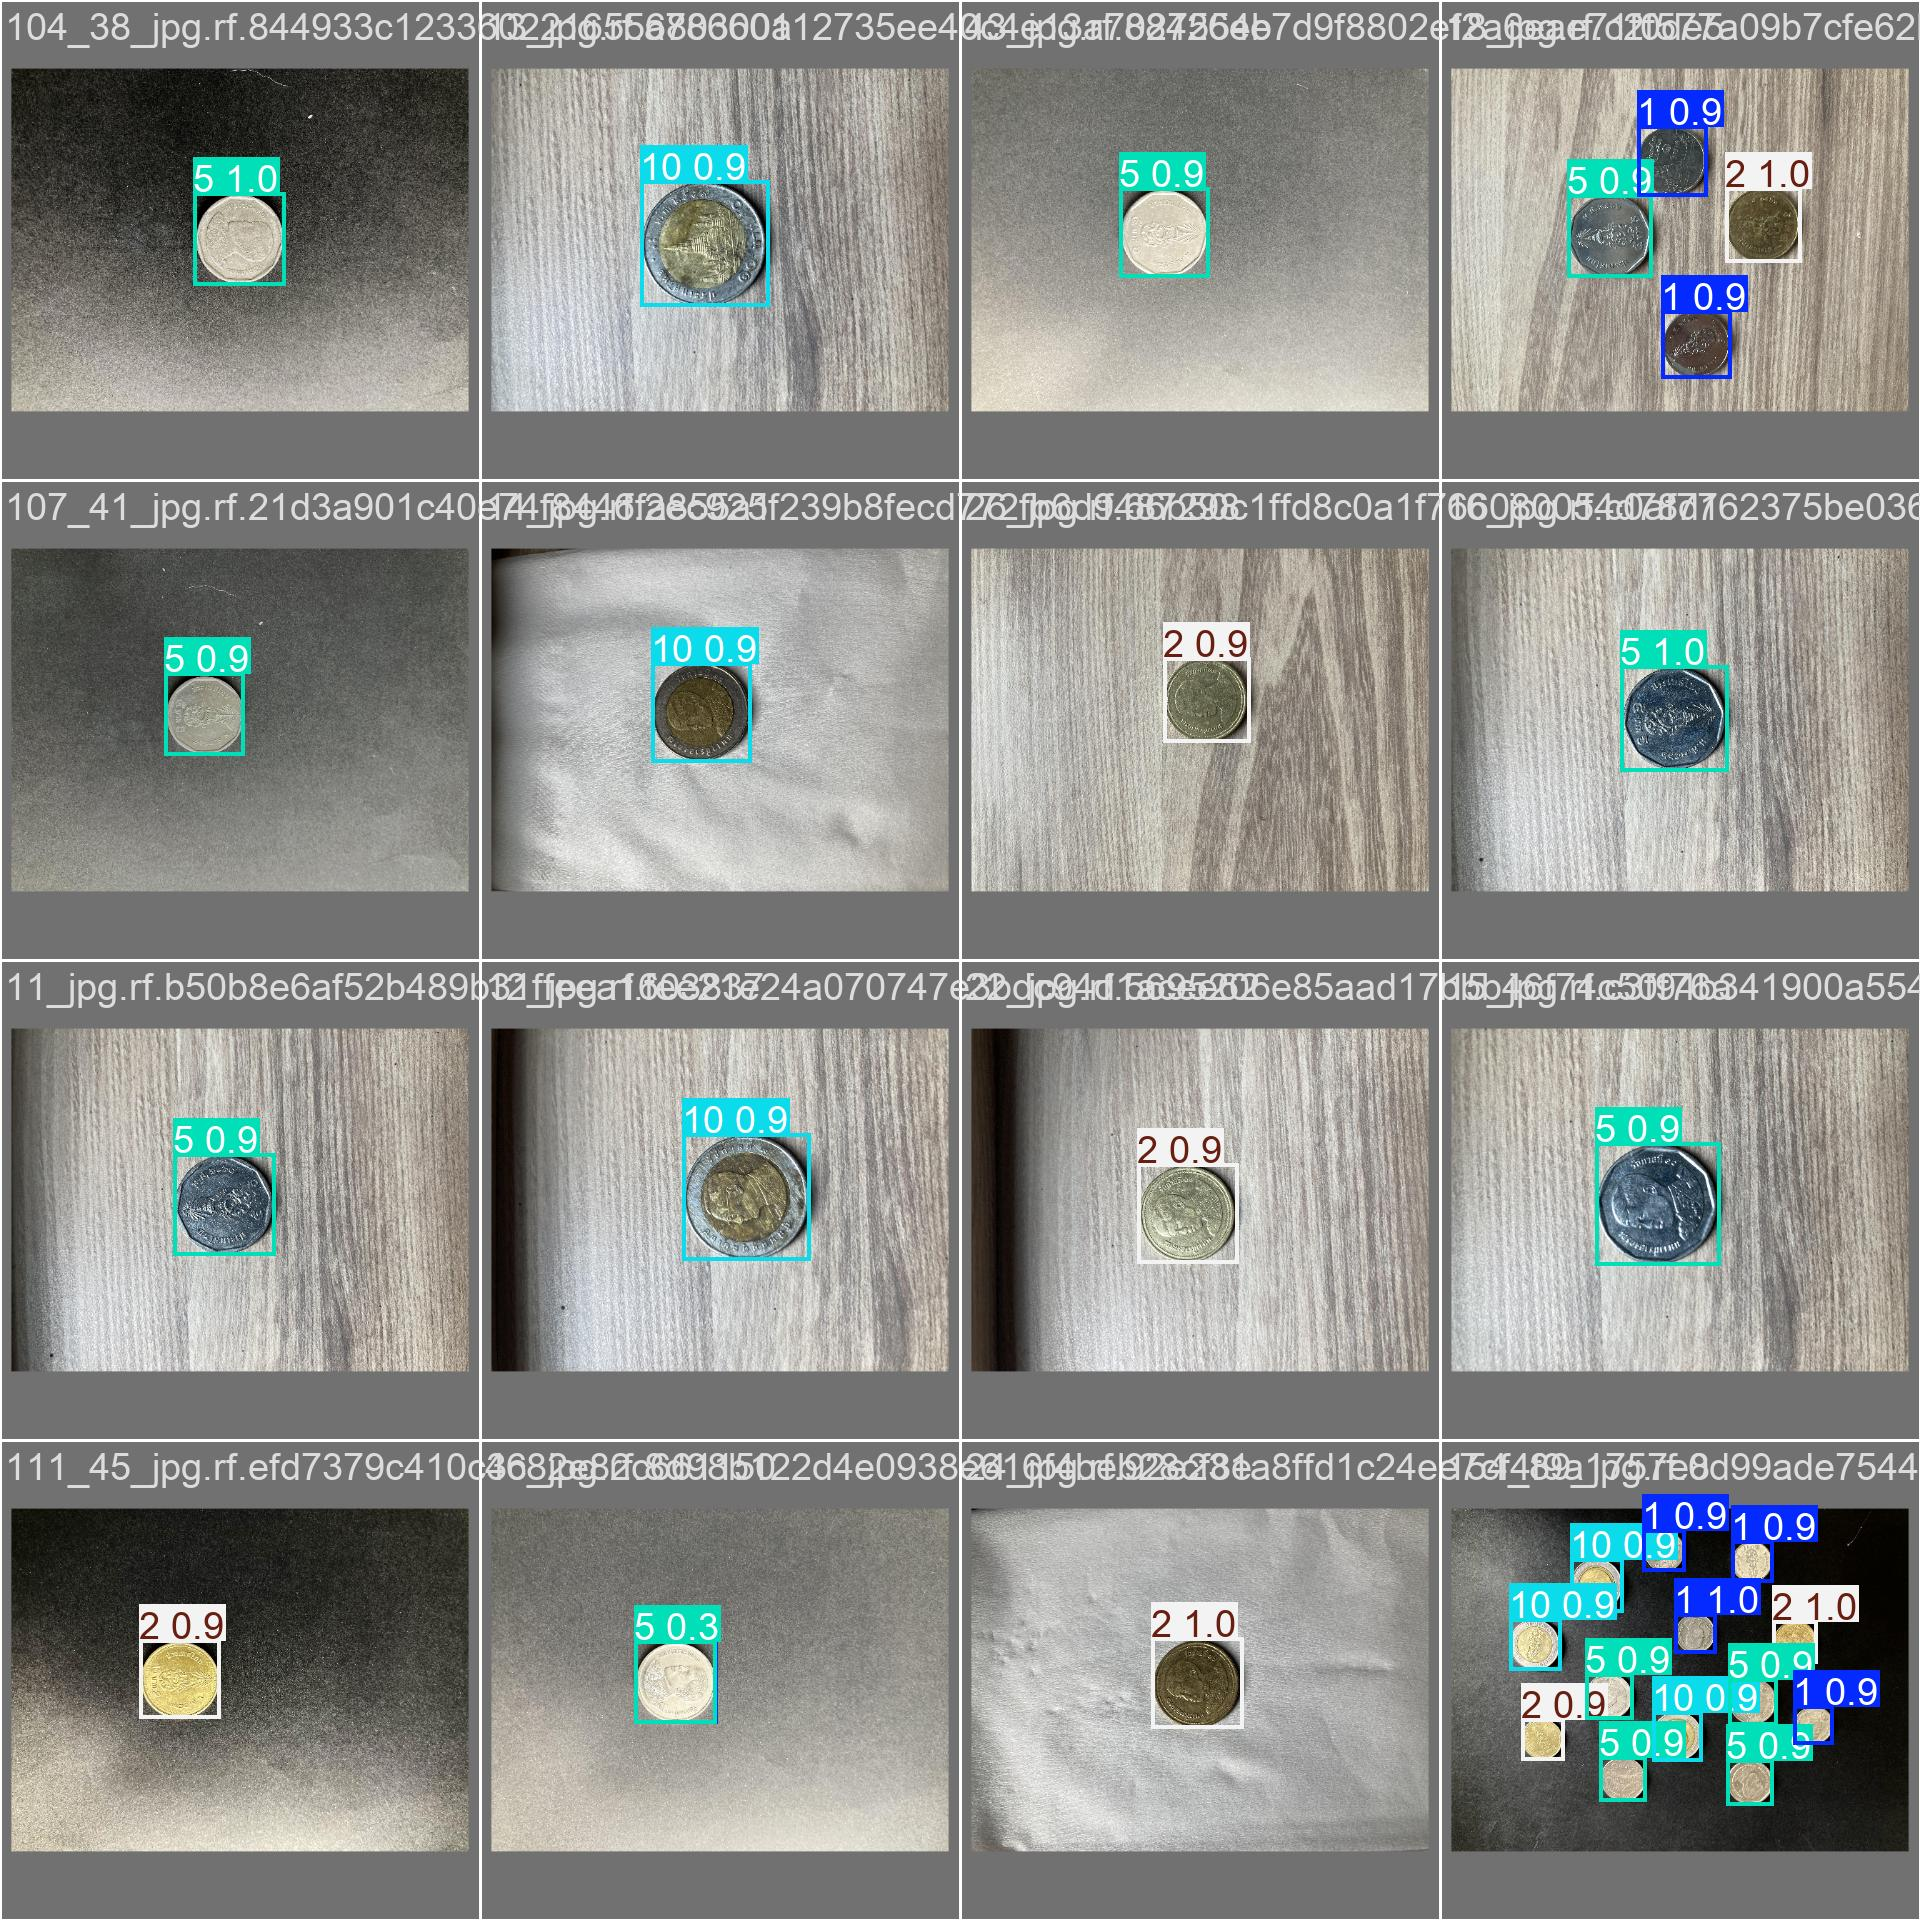

In [33]:
display(IPyImage(filename=f'runs/detect/train/val_batch0_pred.jpg', width=800))

img = PILImage.open("runs/detect/train/val_batch0_pred.jpg")
img.show()